# Figures

In [1]:
import os
path = '/home/lingyu/ssd/Python/'
os.chdir(f'{path}STFoundation/Data')

Below is pure Python code that:

Simulates expression for 2 genes (RAD21, TNFSF11) in 93 samples
– 86 anthracycline‑S, 7 anthracycline‑R
Builds a 2×93 expression matrix
Draws violin plots with overlaid points for each gene

Expression matrix shape: (2, 93)
sample_id          R_01          R_02         R_03          R_04  \
gene                                                               
RAD21      11854.693867  10037.693750  31497.69117  16176.617965   
TNFSF11       61.943589     60.952963     97.86280     95.708191   

sample_id          R_05         R_06         R_07          S_01          S_02  \
gene                                                                            
RAD21      22764.600984  9848.755744  16269.91784  17433.592540  35884.427923   
TNFSF11       52.107750    48.792008     24.32498    207.268725    122.694118   

sample_id          S_03  ...          S_77          S_78          S_79  \
gene                     ...                                             
RAD21      28014.513654  ...  22084.010296  24312.030759  18999.044133   
TNFSF11      196.990861  ...    125.298851     95.798544    134.258290   

sample_id          S_80          S_81          S_82          S_83  \
gen

/tmp/ipykernel_1574710/1896360323.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vp = sns.violinplot(
/tmp/ipykernel_1574710/1896360323.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)
/tmp/ipykernel_1574710/1896360323.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  vp = sns.violinplot(
/tmp/ipykernel_1574710/1896360323.py:172: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=0)


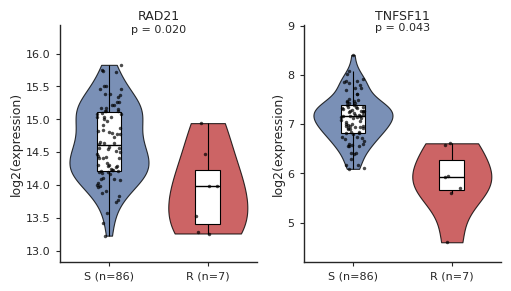

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 1. Simulate expression data
# ============================

# Differential expression statistics (given)
gene_stats = {
    "RAD21": {
        "baseMean": 19699.88625,
        "log2FC":  -0.732995797
    },
    "TNFSF11": {
        "baseMean": 90.17532694,
        "log2FC":  -1.223533633
    }
}

# Sample sizes
n_S = 86   # anthracycline-sensitive
n_R = 7    # anthracycline-resistant

np.random.seed(123)  # for reproducibility

# Create sample IDs
samples_S = [f"S_{i+1:02d}" for i in range(n_S)]
samples_R = [f"R_{i+1:02d}" for i in range(n_R)]
all_samples = samples_S + samples_R

# Long-format expression DataFrame
expr_list = []

for gene, stats in gene_stats.items():
    base_mean = stats["baseMean"]
    log2fc = stats["log2FC"]

    # Assume baseMean is overall mean on linear scale
    # Model means on log2 scale such that:
    #   mean_log2(R) - mean_log2(S) = log2FC
    overall_log2 = np.log2(base_mean)
    mean_log2_R = overall_log2 + log2fc / 2.0
    mean_log2_S = overall_log2 - log2fc / 2.0

    # Standard deviation on log2 scale (tunable)
    sd_log2 = 0.5

    # Simulate log2-expression for each group
    expr_S_log2 = np.random.normal(loc=mean_log2_S, scale=sd_log2, size=n_S)
    expr_R_log2 = np.random.normal(loc=mean_log2_R, scale=sd_log2, size=n_R)

    # Back-transform to linear scale
    expr_S = 2 ** expr_S_log2
    expr_R = 2 ** expr_R_log2

    # Store in long format
    expr_list.append(pd.DataFrame({
        "sample_id": samples_S + samples_R,
        "group":     ["anthracycline-S"] * n_S + ["anthracycline-R"] * n_R,
        "gene":      gene,
        "expression": np.concatenate([expr_S, expr_R])
    }))

expr_df = pd.concat(expr_list, ignore_index=True)

# Build expression matrix (genes x samples)
expr_matrix = (
    expr_df
    .pivot(index="gene", columns="sample_id", values="expression")
    .sort_index()
)
print("Expression matrix shape:", expr_matrix.shape)
print(expr_matrix.head())

# Add log2-transformed expression for plotting
expr_df["log2_expression"] = np.log2(expr_df["expression"] + 1e-8)

# p-values from your DE table (for annotation)
gene_pvals = {
    "RAD21": 0.019553203,
    "TNFSF11": 0.042525405
}

# ============================
# 2. Nature-style aesthetics
# ============================

sns.set_theme(style="ticks", context="paper")

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["axes.labelsize"] = 9
plt.rcParams["xtick.labelsize"] = 8
plt.rcParams["ytick.labelsize"] = 8
plt.rcParams["legend.fontsize"] = 8

palette = {
    "anthracycline-S": "#4C72B0",  # blue
    "anthracycline-R": "#D62728"   # red
}

# ============================
# 3. Plot two genes side by side
# ============================

genes = ["RAD21", "TNFSF11"]

fig, axes = plt.subplots(
    1, 2,
    figsize=(5.2, 3.0),   # width, height in inches
    sharey=False          # do NOT share y-axis
)

for ax, gene in zip(axes, genes):
    df_plot = expr_df[expr_df["gene"] == gene].copy()

    # ---- Violin plot ----
    vp = sns.violinplot(
        data=df_plot,
        x="group",
        y="log2_expression",
        order=["anthracycline-S", "anthracycline-R"],
        inner=None,           # no default inner lines
        cut=0,
        linewidth=0.8,
        palette=palette,
        ax=ax
    )

    # Make violins slightly transparent and add edgecolor
    for pc in vp.collections:
        pc.set_alpha(0.8)
        pc.set_edgecolor("black")

    # ---- Thin boxplot on top ----
    sns.boxplot(
        data=df_plot,
        x="group",
        y="log2_expression",
        order=["anthracycline-S", "anthracycline-R"],
        width=0.25,
        showcaps=False,
        boxprops={"facecolor": "white", "edgecolor": "black", "linewidth": 0.8},
        medianprops={"color": "black", "linewidth": 1.0},
        whiskerprops={"color": "black", "linewidth": 0.8},
        showfliers=False,
        ax=ax
    )

    # ---- Jittered scatter points ----
    sns.stripplot(
        data=df_plot,
        x="group",
        y="log2_expression",
        order=["anthracycline-S", "anthracycline-R"],
        color="black",
        size=2.5,
        jitter=0.12,
        alpha=0.7,
        ax=ax
    )

    # ---- Axes, labels, ticks ----
    group_counts = df_plot["group"].value_counts()
    labels = [
        f"S (n={group_counts.get('anthracycline-S', 0)})",
        f"R (n={group_counts.get('anthracycline-R', 0)})"
    ]
    ax.set_xticklabels(labels, rotation=0)

    ax.set_xlabel("")
    ax.set_ylabel("log2(expression)", labelpad=2)
    ax.set_title(gene, fontsize=9, pad=4)

    ax.grid(False)
    sns.despine(ax=ax, top=True, right=True)

    y_min = df_plot["log2_expression"].min()
    y_max = df_plot["log2_expression"].max()
    ax.set_ylim(y_min - 0.4, y_max + 0.6)

    ax.tick_params(
        axis="both",
        direction="out",
        length=3,
        width=0.8
    )

    # ---- p-value annotation ----
    p_val = gene_pvals.get(gene, None)
    if p_val is not None:
        ax.text(
            0.5,
            y_max + 0.45,
            f"p = {p_val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# ============================
# 4. Save as PDF
# ============================

plt.savefig(f"{path}CNetCox/CNet-Cox/Data/DrugRest/violin_simulation.pdf", dpi=300, bbox_inches="tight")
plt.show()
